# GDP Nowcast — Canada

Monthly nowcast of Canadian gross domestic product (chained 2017 dollars, seasonally adjusted at annual rates)
using employment, CPI, and manufacturing sales as predictors.

**Five models compared:** OLS, Ridge, SVR, Gradient Boosting, Random Forest

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print('All imports successful.')

All imports successful.


---
## 1. Load Data

In [2]:
CSV_PATH = 'data/processed/training_data.csv'
df = pd.read_csv(CSV_PATH, parse_dates=['date'])
print(f'Shape: {df.shape}')
print(f'Date range: {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Columns:\n  {list(df.columns)}')
df.head(3)

Shape: (407, 23)
Date range: 1992-06-01 → 2026-04-01
Columns:
  ['date', 'lfs_value', 'cpi_value', 'mfg_value', 'gdp_value', 'lfs_value_lag_1', 'lfs_value_lag_2', 'lfs_value_lag_3', 'lfs_value_roll_mean_3', 'lfs_value_roll_mean_6', 'lfs_value_growth', 'cpi_value_lag_1', 'cpi_value_lag_2', 'cpi_value_lag_3', 'cpi_value_roll_mean_3', 'cpi_value_roll_mean_6', 'cpi_value_growth', 'mfg_value_lag_1', 'mfg_value_lag_2', 'mfg_value_lag_3', 'mfg_value_roll_mean_3', 'mfg_value_roll_mean_6', 'mfg_value_growth']


,date,lfs_value,cpi_value,mfg_value,gdp_value,lfs_value_lag_1,lfs_value_lag_2,lfs_value_lag_3,lfs_value_roll_mean_3,lfs_value_roll_mean_6,...,cpi_value_lag_3,cpi_value_roll_mean_3,cpi_value_roll_mean_6,cpi_value_growth,mfg_value_lag_1,mfg_value_lag_2,mfg_value_lag_3,mfg_value_roll_mean_3,mfg_value_roll_mean_6,mfg_value_growth
0,1992-06-01,12717.3,84.0,23599825.0,NaN,12736.6,12730.9,12744.9,12728.266667,12748.533333,...,83.6,83.833333,83.616667,0.002387,23121861.0,23079929.0,22774067.0,2.326720e+07,2.297788e+07,0.020672
1,1992-07-01,12732.5,84.2,23340012.0,NaN,12717.3,12736.6,12730.9,12728.800000,12738.916667,...,83.7,84.000000,83.766667,0.002381,23599825.0,23121861.0,23079929.0,2.335390e+07,2.312750e+07,-0.011009
2,1992-08-01,12693.7,84.2,23485737.0,NaN,12732.5,12717.3,12736.6,12714.500000,12725.983333,...,83.8,84.133333,83.916667,0.000000,23340012.0,23599825.0,23121861.0,2.347519e+07,2.323357e+07,0.006244


---
## 2. Prepare Features & Target

In [3]:
TARGET = 'gdp_value'
feature_cols = [c for c in df.columns if c not in ['date', TARGET]]
print(f'Number of features: {len(feature_cols)}')

# Training set = rows where GDP target is published
train = df[df[TARGET].notna()].copy()
X = train[feature_cols]
y = train[TARGET]

# Latest row (may or may not have target) for nowcast
latest = df.iloc[[-1]].copy()
print(f'Training rows: {X.shape[0]}')
print(f'Features:      {X.shape[1]}')
print(f'Latest date:   {latest["date"].iloc[0].date()}')

Number of features: 21
Training rows: 352
Features:      21
Latest date:   2026-04-01


---
## 3. Define Models

In [4]:
models = {
    'OLS Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'SVR (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        ('svr', SVR(kernel='rbf', C=1e4, gamma='scale', epsilon=0.1))
    ]),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=200, max_depth=3, learning_rate=0.1, random_state=42
    ),
    'Random Forest': RandomForestRegressor(
        n_estimators=100, random_state=42
    ),
}

print(f'{len(models)} models defined:')
for name in models:
    print(f'  • {name}')

5 models defined:
  • OLS Regression
  • Ridge Regression
  • SVR (RBF)
  • Gradient Boosting
  • Random Forest


---
## 4. TimeSeries Cross-Validation (4-fold)

In [5]:
tscv = TimeSeriesSplit(n_splits=4)

cv_results = {}  # name -> {'cv_scores': [...], 'cv_mae': float, 'cv_mae_pct': float}

for name, model in models.items():
    scores = []
    for tr_idx, te_idx in tscv.split(X):
        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]
        
        model.fit(X_tr, y_tr)
        preds = model.predict(X_te)
        scores.append(mean_absolute_error(y_te, preds))
    
    cv_mae = float(np.mean(scores))
    cv_mae_pct = 100 * cv_mae / float(y.mean())
    cv_results[name] = {'cv_scores': scores, 'cv_mae': cv_mae, 'cv_mae_pct': cv_mae_pct}
    print(f'{name:25s}  CV MAE = {cv_mae:>10,.0f}  ({cv_mae_pct:.2f}% of mean GDP)')

OLS Regression             CV MAE =     60,638  (3.39% of mean GDP)
Ridge Regression           CV MAE =     59,790  (3.34% of mean GDP)


SVR (RBF)                  CV MAE =    307,756  (17.20% of mean GDP)


Gradient Boosting          CV MAE =    105,725  (5.91% of mean GDP)


Random Forest              CV MAE =    107,944  (6.03% of mean GDP)


---
## 5. Nowcast — Latest Month

In [6]:
X_latest = latest[feature_cols]
actual = latest[TARGET].iloc[0]
actual_val = float(actual) if not pd.isna(actual) else None

nowcast_results = []

for name, model in models.items():
    # Refit on ALL training data
    model.fit(X, y)
    pred = float(model.predict(X_latest)[0])
    
    error = abs(pred - actual_val) if actual_val is not None else None
    error_pct = (100 * error / actual_val) if (actual_val is not None and actual_val != 0) else None
    
    nowcast_results.append({
        'Model': name,
        'Nowcast': pred,
        'Error': error,
        'Error %': error_pct,
        'CV MAE': cv_results[name]['cv_mae'],
        'CV MAE %': cv_results[name]['cv_mae_pct'],
    })

results_df = pd.DataFrame(nowcast_results)

if actual_val is not None:
    print(f'Actual GDP for {latest["date"].iloc[0].date()}: {actual_val:,.0f}')
else:
    print(f'GDP not yet published for {latest["date"].iloc[0].date()} — showing nowcasts.')

Actual GDP for 2026-04-01: 2,352,903


---
## 6. Model Comparison Table

In [7]:
display_df = results_df.copy()
display_df['Nowcast'] = display_df['Nowcast'].apply(lambda x: f'{x:,.0f}')
display_df['Error'] = display_df['Error'].apply(lambda x: f'{x:,.0f}' if x is not None else 'N/A')
display_df['Error %'] = display_df['Error %'].apply(lambda x: f'{x:.2f}%' if x is not None else 'N/A')
display_df['CV MAE'] = display_df['CV MAE'].apply(lambda x: f'{x:,.0f}')
display_df['CV MAE %'] = display_df['CV MAE %'].apply(lambda x: f'{x:.2f}%')

# Highlight best CV MAE
best_cv_idx = results_df['CV MAE'].idxmin()
print('Model Comparison (sorted by CV MAE ↑ best):')
print('=' * 90)
print(f'{"Model":25s} {"Nowcast":>14s} {"Error":>12s} {"Error%":>8s} {"CV MAE":>12s} {"CV MAE%":>8s}')
print('-' * 90)
for i, row in display_df.iterrows():
    marker = ' ← best CV' if i == best_cv_idx else ''
    print(f'{row["Model"]:25s} {row["Nowcast"]:>14s} {row["Error"]:>12s} {row["Error %"]:>8s} {row["CV MAE"]:>12s} {row["CV MAE %"]:>8s}{marker}')
print('=' * 90)

Model Comparison (sorted by CV MAE ↑ best):
Model                            Nowcast        Error   Error%       CV MAE  CV MAE%
------------------------------------------------------------------------------------------
OLS Regression                 2,416,653       63,750    2.71%       60,638    3.39%
Ridge Regression               2,416,779       63,876    2.71%       59,790    3.34% ← best CV
SVR (RBF)                      2,193,949      158,954    6.76%      307,756   17.20%
Gradient Boosting              2,352,775          128    0.01%      105,725    5.91%
Random Forest                  2,348,573        4,330    0.18%      107,944    6.03%


---
## 7. Plot — All Model Nowcasts vs Actual GDP

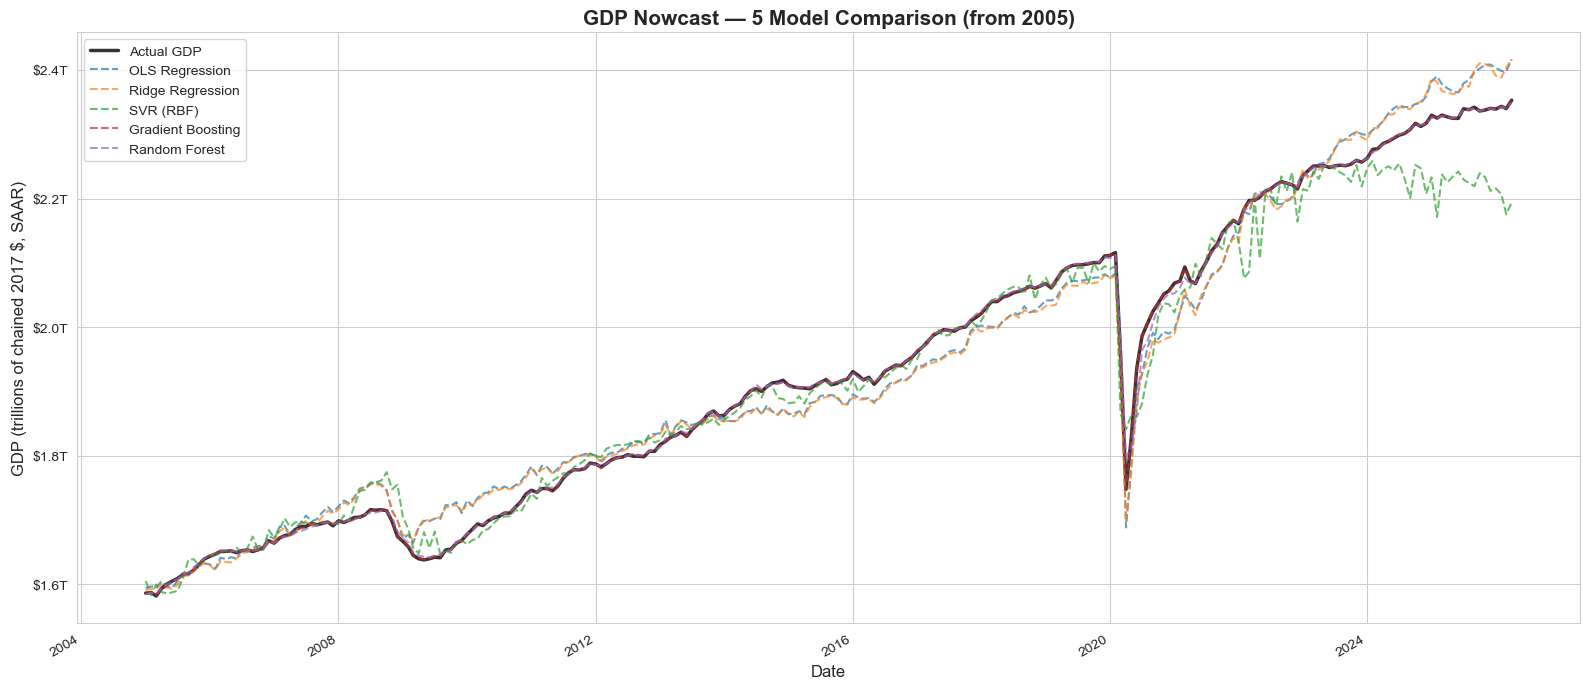

In [8]:
# Get predictions across all training+test dates for each model
predictions_df = df[['date', TARGET]].copy()

for name, model in models.items():
    # Predict on all rows that have features (including those without target)
    all_X = df[feature_cols]
    predictions_df[f'{name}'] = model.predict(all_X)

# Plot
fig, ax = plt.subplots(figsize=(16, 7))

# Actual GDP
date_min = pd.Timestamp('2005-01-01')
plot_mask = predictions_df['date'] >= date_min

ax.plot(predictions_df.loc[plot_mask, 'date'], 
        predictions_df.loc[plot_mask, TARGET] / 1e6,
        label='Actual GDP', color='black', linewidth=2.5, alpha=0.8)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for idx, name in enumerate(models.keys()):
    ax.plot(predictions_df.loc[plot_mask, 'date'],
            predictions_df.loc[plot_mask, f'{name}'] / 1e6,
            label=f'{name}', color=colors[idx], linewidth=1.5, alpha=0.7, linestyle='--')

ax.set_title('GDP Nowcast — 5 Model Comparison (from 2005)', fontsize=15, fontweight='bold')
ax.set_ylabel('GDP (trillions of chained 2017 $, SAAR)', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}T'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

---
## 8. Feature Importance (Random Forest)

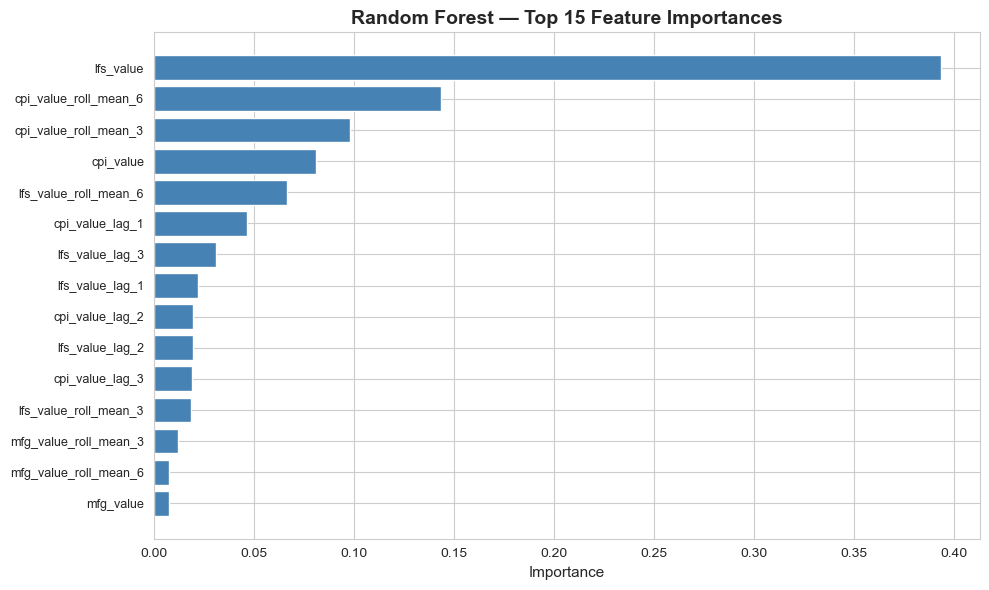

In [9]:
rf_model = models['Random Forest']
importances = rf_model.feature_importances_
feat_imp_df = pd.DataFrame({'feature': feature_cols, 'importance': importances})
feat_imp_df = feat_imp_df.sort_values('importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feat_imp_df['feature'], feat_imp_df['importance'], color='steelblue')
ax.set_title('Random Forest — Top 15 Feature Importances', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance', fontsize=11)
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.show()

---
## 9. Summary

**Best model by CV MAE:** the one with the arrow marker in the table above.

**Nowcast for the latest month:** shown in the comparison table.